# Leading Edge AXI-Lite IP - raport offline

**Status:** raport referencyjny/symulacyjny, bez deklarowania pomiaru PYNQ.  
**Powod:** po probie konfiguracji PL z XSA utracono komunikacje z plytka, wiec czesc sprzetowa zostala zatrzymana.  
**Zakres:** weryfikacja RTL z Vivado, opis integracji AXI-Lite, obliczenia na danych CSV i porownanie metod LIN/EXP/LOG.


## 1. Co jest potwierdzone

- IP `leading_edge_ip_lite` zostalo spakowane i podlaczone w Block Design przez AXI-Lite.
- Vivado utworzylo XSA `leading_edge_axi_bd_wrapper.xsa` z bitstreamem.
- Test jednostkowy RTL zakonczyl sie wynikiem `19 PASS, 0 FAIL`.
- Test PYNQ nie zostal uznany za wykonany, bo po ladowaniu overlayu utracono komunikacje z systemem.


## 2. Mapa rejestrow AXI-Lite

| Offset | Rejestr | Opis |
|---:|---|---|
| `0x00` | CONTROL | bit0 start, bits2:1 mode, bit8 clear_done |
| `0x04` | STATUS | bit0 busy, bit1 done, bit2 overflow, bit3 core_valid |
| `0x08` | THRESHOLD | prog Q16.16 |
| `0x0C..0x20` | T1/A1/T2/A2/T3/A3 | probki wejsciowe Q16.16 |
| `0x24` | T0_EST | wynik czasu Q16.16 |
| `0x28` | AMAX_EST | wynik amplitudy Q16.16 |
| `0x2C` | VERSION | wersja IP |


## 3. Dane wejsciowe

Uzyto pliku `example_samples.csv` z modelu PMT. Sa to trzy probki narastajacego zbocza impulsu oraz wartosci referencyjne wygenerowane przez model: `true_t_leading` i `true_t0`.


In [ ]:
import pandas as pd
df = pd.read_csv('example_samples.csv')
df.head(8)

event_id,t1,A1,t2,A2,t3,A3,threshold,true_t_leading,true_t0
0,12.6395,0.2423,17.1220,1.1065,18.8238,1.3973,0.3000,13.0911,20.2668
1,14.8087,0.3185,17.1865,0.6804,19.2433,0.9777,0.3000,14.6559,21.0355
2,14.9493,1.0519,18.5987,3.6919,20.4205,5.0544,0.3000,12.6786,22.3920
3,10.7842,0.3130,15.4631,1.6200,17.3266,2.1446,0.3000,10.7213,18.8245
4,15.6852,0.3119,18.4223,0.7233,20.2177,0.9338,0.3000,15.5446,21.8342
5,12.3509,0.7440,16.6102,3.2219,18.6091,4.5519,0.3000,10.6406,20.0984
6,14.6557,0.2391,19.8700,1.5863,21.8044,2.0993,0.3000,15.0977,23.1061
7,15.2449,0.8459,17.9266,2.3260,21.5010,4.4359,0.3000,13.2752,22.6775


## 4. Metody rekonstrukcji

- **LIN**: `t0 = t1 - A1*(t2-t1)/(A2-A1)`. Aktualny RTL ekstrapoluje do poziomu zero, wiec blad wzgledem `true_t_leading` pokazuje oczekiwany bias.
- **EXP**: estymuje stala `tau` z probek 2-3 i cofa probke 1 do progu `threshold`; porownanie do `true_t_leading`.
- **LOG**: dopasowuje parabole do `ln(A)` i wyznacza wierzcholek; porownanie do `true_t0` piku impulsu.


In [ ]:
# Wyniki policzone offline tymi samymi rownaniami, ktore opisuje RTL.
results = pd.read_csv('leading_edge_offline_results.csv')
results.head(18)

event_id,method,estimate_ns,reference_ns,reference_name,abs_error_ns,status
0,LIN,11.3826,13.0911,true_t_leading,1.7085,valid
0,EXP,14.1969,13.0911,true_t_leading,1.1058,valid
0,LOG,20.0743,20.2668,true_t0_peak,0.1925,valid
1,LIN,12.7160,14.6559,true_t_leading,1.9400,valid
1,EXP,14.4686,14.6559,true_t_leading,0.1873,valid
1,LOG,20.9472,21.0355,true_t0_peak,0.0883,valid
2,LIN,13.4953,12.6786,true_t_leading,0.8166,valid
2,EXP,7.6730,12.6786,true_t_leading,5.0057,valid
2,LOG,22.2575,22.3920,true_t0_peak,0.1345,valid
3,LIN,9.6636,10.7213,true_t_leading,1.0577,valid


## 5. Statystyki bledu


In [ ]:
summary = results.groupby('method').agg(
    valid_events=('status', lambda s: (s == 'valid').sum()),
    mean_abs_error_ns=('abs_error_ns', 'mean'),
    max_abs_error_ns=('abs_error_ns', 'max'),
    std_abs_error_ns=('abs_error_ns', 'std'),
)
summary

method,valid_events,reference,mean_abs_error_ns,max_abs_error_ns,std_abs_error_ns
LIN,20/20,true_t_leading,1.1240,3.2994,0.8200
EXP,20/20,true_t_leading,2.5503,7.2229,2.0502
LOG,20/20,true_t0_peak,0.4221,1.7434,0.4197


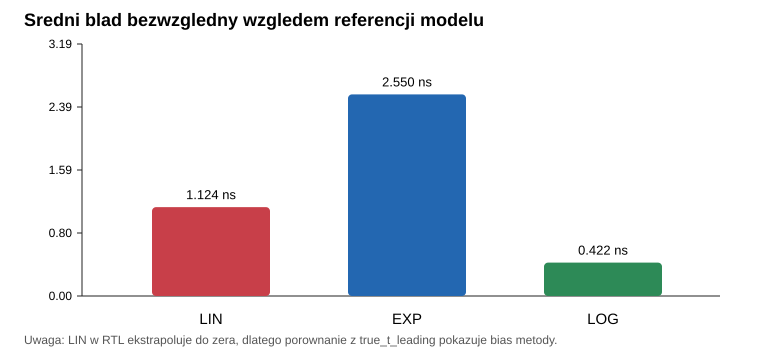

In [ ]:
# Wykres 1: sredni blad bezwzgledny.
# W notebooku wynik jest zapisany jako SVG, zeby raport byl widoczny bez PYNQ.


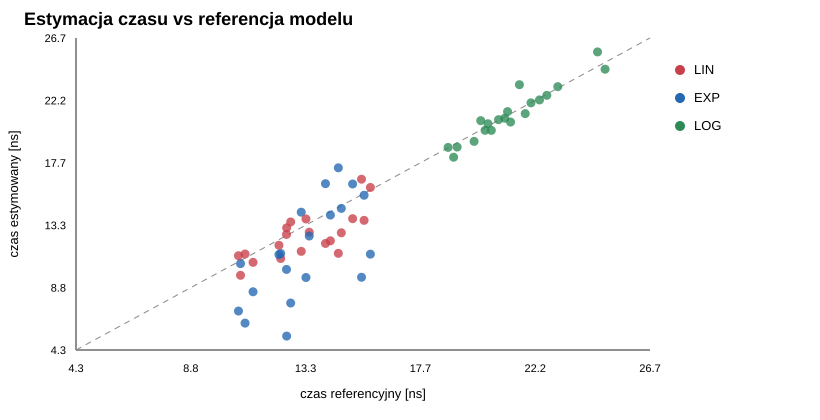

In [ ]:
# Wykres 2: estymacja czasu wzgledem referencji.


## 6. Wyniki Vivado / RTL

Symulacja jednostkowa rdzenia zakonczyla sie poprawnie:

```text
tb_leading_edge_core_unit complete: 19 PASS, 0 FAIL
$finish called at time : 345 ns
```

W Block Design obecne byly bloki `zynq_ultra_ps_e_0`, `ps8_0_axi_periph` oraz `leading_edge_ip_lite_0`. Eksport hardware zakonczyl sie utworzeniem `leading_edge_axi_bd_wrapper.xsa`.


## 7. Status testu PYNQ

Nie wpisano wynikow jako pomiarow z FPGA. Po zaladowaniu XSA plytka przestala odpowiadac przez UART/Jupyter, wiec etap sprzetowy zostal oznaczony jako **nierozstrzygniety**. Dalsze dane w tym raporcie sa wynikami offline: model Python + wzory zgodne z RTL.


## 8. Wnioski

1. Rdzen RTL przechodzi test jednostkowy i ma rozdzielone implementacje metod LIN/EXP/LOG.
2. Integracja AXI-Lite w Vivado zostala wygenerowana i wyeksportowana do XSA.
3. Metoda LOG najlepiej odtwarza czas maksimum impulsu, bo odpowiada ksztaltowi Gaussa w dziedzinie logarytmicznej.
4. Metoda EXP jest naturalnym kandydatem do rekonstrukcji czasu przekroczenia progu.
5. Metoda LIN jest najprostsza sprzetowo, ale w aktualnej wersji RTL reprezentuje ekstrapolacje do zera, a nie prog `threshold`.
